# 02 — LFMC 数据读取与清洗（不做时空匹配）

本 notebook 仅完成 LFMC 点位数据的 **读取 + 标准化 + QC 标记 +（可选）站点-日聚合 + 导出**。

**不包含：**
- 与 VOD 的时空匹配
- 栅格化/像元化
- 机器学习建模或反演

---

## 产物

输出到 `configs/lfmc.yaml` 指定的 `out_dir`：
1. `lfmc_std.parquet`：标准化 + QC flags（尽量不删软异常）
2. `lfmc_site_day.parquet`：站点-日聚合（严格视图后聚合）
3. `lfmc_qc_report.json`：QC 统计报告与摘要


In [1]:
import os, sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 让 notebook 能 import function/ 下的模块（兼容 VSCode Jupyter 的 cwd 行为）
cwd = Path.cwd().resolve()
if (cwd / "configs" / "lfmc.yaml").exists() and (cwd / "function").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "configs" / "lfmc.yaml").exists() and (cwd.parent / "function").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("找不到项目根目录：未发现 configs/lfmc.yaml 与 function/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import importlib
import function.lfmc.lfmc_clean as lfmc_clean
import function.lfmc.lfmc_qc as lfmc_qc
import function.lfmc.lfmc_io as lfmc_io
import function.lfmc.lfmc_export as lfmc_export
import function.lfmc.lfmc_dedup as lfmc_dedup

importlib.reload(lfmc_clean)
importlib.reload(lfmc_qc)
importlib.reload(lfmc_io)
importlib.reload(lfmc_export)
importlib.reload(lfmc_dedup)

from function.lfmc.lfmc_io import read_lfmc_raw
from function.lfmc.lfmc_clean import standardize_columns
from function.lfmc.lfmc_qc import add_qc_flags, make_strict_view
from function.lfmc.lfmc_export import export_parquet, export_report, summarize

# 如果你创建了 function/lfmc/lfmc_dedup.py
from function.lfmc.lfmc_dedup import deduplicate_site_day


## 1) 读取配置（configs/lfmc.yaml）

这里读取：
- 原始 xlsx 路径与 sheet 名称
- 字段映射（columns）
- QC 基础阈值（lfmc_min/max）
- 去重聚合策略（dedup_strategy）
- 输出目录与文件名


In [2]:
cfg_path = PROJECT_ROOT / "configs" / "lfmc.yaml"
cfg_all = yaml.safe_load(open(cfg_path, "r", encoding="utf-8"))
cfg = cfg_all["lfmc"]

cfg


{'raw_path': 'G:/data/Globe LFMC/Globe-LFMC-2.0 final.xlsx',
 'sheet_name': 'LFMC data',
 'out_dir': 'G:/data/Globe LFMC/processed',
 'out_std_name': 'lfmc_std.parquet',
 'out_dedup_name': 'lfmc_site_day.parquet',
 'out_report_name': 'lfmc_qc_report.json',
 'out_grid_day_name': 'lfmc_grid_day_0p1.parquet',
 'normalize_to_date': True,
 'dedup_strategy': 'median',
 'columns': {'sorting_id': 'Sorting ID',
  'site_name': 'Site Name',
  'lat': 'Latitude',
  'lon': 'Longitude',
  'date': 'Sampling Date (YYYYMMDD)',
  'time': 'Sampling Time (hh:mm)',
  'lfmc': 'LFMC (%)',
  'extra_info_flag': 'Extra Info Flag',
  'isolated_iforest': 'Isolated data point',
  'species': 'Species collected',
  'functional_type': 'Species functional type',
  'individual_or_mean': 'Individual or mean',
  'protocol': 'Protocol',
  'source': 'Database'},
 'lfmc_min': 0,
 'lfmc_max': 400,
 'suspect_keywords': ['outlier',
  'anomal',
  'error',
  'suspect',
  'dead',
  'flower',
  'bud',
  'wrong',
  'invalid']}

## 2) 读取原始 LFMC 表（LFMC Data sheet）

输出：
- `df_raw`：原始 DataFrame（未做任何清洗）
检查点：
- 行数/列数是否合理
- 关键列是否存在（比如 lat/lon/date/lfmc）


In [3]:
df_raw = read_lfmc_raw(cfg)

print("df_raw shape:", df_raw.shape)
print("first 20 columns:", list(df_raw.columns[:20]))
df_raw.head(3)


df_raw shape: (293796, 38)
first 20 columns: ['Sorting ID', 'Contact', 'Site name', 'Country', 'State/Region', 'Latitude (WGS84, EPSG:4326)', 'Longitude (WGS84, EPSG:4326)', 'Sampling date (YYYYMMDD)', 'Sampling time (24h format)', 'Protocol', 'LFMC value (%)', 'Species collected', 'Species functional type', 'Individual sample or mean value', 'Old or new leaves', 'Elevation (m.a.s.l)', 'Slope (%)', 'Extra information/Quality Flag', 'Isolated data point', 'Reference']


,Sorting ID,Contact,Site name,Country,State/Region,"Latitude (WGS84, EPSG:4326)","Longitude (WGS84, EPSG:4326)",Sampling date (YYYYMMDD),Sampling time (24h format),Protocol,...,Precipitation sum 12 weeks before (mm/day),2m Relative Humidity at 06h (%),2m Relative Humidity at 09h (%),2m Relative Humidity at 12h (%),2m Relative Humidity at 15h (%),2m Air Temperature 24h max (K),2m Air Temperature 24h mean (K),Vapour Pressure 24h mean (hPa),10m Wind Speed 24h mean (m/s),2m Dewpoint Temperature 24h mean (K)
0,1,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-04-06,12:05:00,16,...,326.990002,73.560074,75.661018,58.473328,55.678799,297.209686,291.944214,15.791007,3.237640,286.945831
1,2,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-12-17,12:48:00,16,...,255.830002,90.797096,69.246300,52.833767,49.400108,298.885498,294.555634,17.334539,5.512757,288.346405
2,3,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-12-17,12:48:00,16,...,255.830002,90.797096,69.246300,52.833767,49.400108,298.885498,294.555634,17.334539,5.512757,288.346405


## 3) 标准化字段（统一列名、类型、日期解析）

`standardize_columns()` 会做：
- 根据 `cfg.columns` 重命名关键列
- 转换 `lat/lon/lfmc` 为数值
- 解析采样日期/时间为 `sampling_datetime`，并生成 `date`（日尺度）
- 生成稳定的 `site_id`
- 生成辅助列：`year`, `doy`

输出：
- `df_std`：标准化后的 DataFrame（尚未做 QC 筛选）


In [4]:
df_std = standardize_columns(df_raw, cfg)

# 核心列：只检查标准化后（被函数改名/生成）的列
core_cols = ["sorting_id", "site_name", "lat", "lon", "date", "lfmc_pct"]
present = [c for c in core_cols if c in df_std.columns]

print("df_std shape:", df_std.shape)
print("core columns present:", present)

df_std[present].head(5)


df_std shape: (293796, 43)
core columns present: ['sorting_id', 'site_name', 'lat', 'lon', 'date', 'lfmc_pct']


,sorting_id,site_name,lat,lon,date,lfmc_pct
0,1,ArgBA1,-35.267417,-57.614278,2009-04-06,210.085306
1,2,ArgBA1,-35.267417,-57.614278,2009-12-17,167.272112
2,3,ArgBA1,-35.267417,-57.614278,2009-12-17,377.164808
3,4,ArgBA1,-35.267417,-57.614278,2010-03-08,94.099472
4,5,ArgBA1,-35.267417,-57.614278,2010-03-08,340.685939


## 4) 标准化质量检查（快速 sanity check）

目标：确认 date/坐标/LFMC 的解析没有明显问题。

检查点：
- date 是否为 datetime 类型、是否存在大量 NaT
- lat/lon 是否落在合理范围
- lfmc_pct 是否数值、是否出现明显异常（比如全部 NaN）


In [5]:
print("date dtype:", df_std["date"].dtype if "date" in df_std.columns else None)
print("missing date ratio:", float(df_std["date"].isna().mean()) if "date" in df_std.columns else None)

if "lat" in df_std.columns and "lon" in df_std.columns:
    print("lat range:", float(np.nanmin(df_std["lat"])), float(np.nanmax(df_std["lat"])))
    print("lon range:", float(np.nanmin(df_std["lon"])), float(np.nanmax(df_std["lon"])))

print("lfmc missing ratio:", float(df_std["lfmc_pct"].isna().mean()))
df_std["lfmc_pct"].describe()

date dtype: datetime64[ns]
missing date ratio: 0.0
lat range: -42.848333333333336 65.11638889
lon range: -155.5469444 150.9244144
lfmc missing ratio: 0.0


count    293796.000000
mean        110.243562
std        1155.984285
min           0.000000
25%          78.677723
50%          97.583422
75%         121.000000
max      599999.000000
Name: lfmc_pct, dtype: float64

## 5) 添加 QC flags（不删除软异常）

我们按“可追溯”原则：
- 硬错误：`qc_hard=1`（如缺日期/坐标越界/LFMC 越界），可用于严格过滤
- 软异常：`provider_suspect`（来自 extra_info_flag 关键词）、`isolated_iforest`（论文的离群标记）等

输出：
- `df_std_qc`：标准化 + QC flags
- `report`：QC 计数报告（dict）


In [6]:
df_std_qc, report = add_qc_flags(df_std, cfg)

print("QC report:")
for k, v in report.items():
    print(f"  {k}: {v}")

qc_cols = ["qc_hard", "bad_date", "bad_coord", "bad_lfmc", "provider_suspect", "isolated_iforest",
           "site_coord_conflict", "coord_site_conflict"]
qc_cols = [c for c in qc_cols if c in df_std_qc.columns]

df_std_qc[qc_cols].head(5)


QC report:
  n_rows: 293796
  n_qc_hard: 870
  n_bad_date: 0
  n_bad_coord: 0
  n_bad_lfmc: 870
  n_provider_suspect: 867
  n_isolated_iforest: 6245
  n_site_coord_conflict: 0
  n_coord_site_conflict: 971
  n_dead_protocol: 35694


,qc_hard,bad_date,bad_coord,bad_lfmc,provider_suspect,isolated_iforest,site_coord_conflict,coord_site_conflict
0,0,0,0,0,0,False,0,0
1,0,0,0,0,0,False,0,0
2,0,0,0,0,0,False,0,0
3,0,0,0,0,0,False,0,0
4,0,0,0,0,0,True,0,0


## 6) 生成严格视图（Strict view）

默认策略（你已确认）：
- 仅剔除 `qc_hard==1` 的记录
- **不**剔除 `isolated_iforest`（离群标记）
- **不**剔除 `provider_suspect`（文本弱提示）

输出：
- `df_strict_live`


In [7]:
df_strict_live = make_strict_view(
    df_std_qc,
    drop_isolated_iforest=False,
    drop_provider_suspect=False,
    drop_dead_protocol=True,    # 剔除 dead_protocol==1
)

print("df_strict_live shape:", df_strict_live.shape)
print("strict_live summary:", summarize(df_strict_live))


df_strict_live shape: (257484, 51)
strict_live summary: {'n_rows': 257484, 'lfmc_min': 0.0, 'lfmc_max': 400.0, 'lfmc_mean': 108.19336367179464, 'date_min': '1977-04-14 00:00:00', 'date_max': '2023-01-30 00:00:00', 'n_sites': 2158}


## 7) 可选：站点-日聚合（site_id + date）

目的：
- 同一站点同一天可能有多次采样或多条记录
- 我们输出一个“站点-日”版本，方便后续与日尺度遥感数据耦合（但本阶段不做匹配）

策略由 `cfg.dedup_strategy` 控制：
- median / mean / last


In [8]:
strategy = cfg.get("dedup_strategy", "median")
df_site_day = deduplicate_site_day(df_strict_live, strategy=strategy)

print("df_site_day shape:", df_site_day.shape)
df_site_day.head(5)


df_site_day shape: (147695, 12)


,site_id,date,veg_type,lfmc_pct,lat,lon,n_obs,site_name,source,protocol,species,veg_type_unknown_flag
0,001940df4d6b,2008-11-18,Shrub,102.907332,-36.25925,-67.161694,3,ArgLP5,"Yebra, M.,Beget, M.E., Oricchio, P., Di Bell...",16,Condalia microphylla,0
1,001940df4d6b,2009-02-11,Shrub,53.487191,-36.25925,-67.161694,3,ArgLP5,"Yebra, M.,Beget, M.E., Oricchio, P., Di Bell...",16,Condalia microphylla,0
2,001940df4d6b,2009-03-17,Shrub,54.496444,-36.25925,-67.161694,3,ArgLP5,"Yebra, M.,Beget, M.E., Oricchio, P., Di Bell...",16,Condalia microphylla,0
3,001940df4d6b,2009-11-29,Shrub,69.321630,-36.25925,-67.161694,2,ArgLP5,"Yebra, M.,Beget, M.E., Oricchio, P., Di Bell...",16,Condalia microphylla,0
4,001940df4d6b,2009-11-29,Tree,107.027779,-36.25925,-67.161694,1,ArgLP5,"Yebra, M.,Beget, M.E., Oricchio, P., Di Bell...",16,Prosopis flexuosa,0


## 附7：站点-日 → 0.1°网格-日 聚合

In [9]:
# -----------------------------
# 7.5) site-day -> 0.1° grid-day aggregation
# grid centers:
#   lat:  89.95, 89.85, ..., -89.95  (step -0.1)
#   lon: -179.95, -179.85, ..., 179.95 (step +0.1)
# -----------------------------

def _to_grid_center_lat(lat: pd.Series) -> pd.Series:
    """
    Map latitude to nearest 0.1° grid center aligned to 89.95..-89.95.
    Formula (center index k):
      center = 89.95 - 0.1*k
      k = round((89.95 - lat)/0.1)
    """
    lat = pd.to_numeric(lat, errors="coerce")
    k = np.rint((89.95 - lat) / 0.1)
    center = 89.95 - 0.1 * k
    # clamp to valid bounds
    center = np.clip(center, -89.95, 89.95)
    # avoid -0.0
    center = np.where(np.isclose(center, 0.0), 0.0, center)
    return pd.Series(center, index=lat.index)

def _to_grid_center_lon(lon: pd.Series) -> pd.Series:
    """
    Map longitude to nearest 0.1° grid center aligned to -179.95..179.95.
    We first wrap lon into [-180, 180), then:
      center = -179.95 + 0.1*j
      j = round((lon - (-179.95))/0.1)
    """
    lon = pd.to_numeric(lon, errors="coerce")
    # wrap to [-180, 180)
    lon_wrapped = ((lon + 180) % 360) - 180

    j = np.rint((lon_wrapped + 179.95) / 0.1)
    center = -179.95 + 0.1 * j
    # clamp
    center = np.clip(center, -179.95, 179.95)
    # fix -0.0
    center = np.where(np.isclose(center, 0.0), 0.0, center)
    return pd.Series(center, index=lon.index)

def aggregate_to_grid_day(
    df_site_day: pd.DataFrame,
    strategy: str = "median",
    keep_cols: list[str] | None = None
) -> pd.DataFrame:
    """
    Aggregate site-day records to 0.1° grid-day.
    Group key: (date, grid_lat, grid_lon, veg_type)

    strategy: 'median' | 'mean' | 'last'
    keep_cols: extra columns to keep by 'first' (optional), e.g. ['source']
    """
    df = df_site_day.copy()

    # 1) grid mapping
    df["grid_lat"] = _to_grid_center_lat(df["lat"])
    df["grid_lon"] = _to_grid_center_lon(df["lon"])

    # 2) choose reducer
    strategy = (strategy or "median").lower()
    if strategy not in {"median", "mean", "last"}:
        raise ValueError("strategy must be one of: median / mean / last")

    if strategy == "median":
        agg_lfmc = "median"
    elif strategy == "mean":
        agg_lfmc = "mean"
    else:  # last
        agg_lfmc = "last"

    # 3) group
    gcols = ["date", "grid_lat", "grid_lon"]
    if "veg_type" in df.columns:
        gcols.append("veg_type")

    agg_dict = {
        "lfmc_pct": agg_lfmc,
        "n_obs": "sum" if "n_obs" in df.columns else "size",
        "site_id": "nunique",  # number of unique sites contributing in this grid-day
    }

    if keep_cols:
        for c in keep_cols:
            if c in df.columns and c not in agg_dict:
                agg_dict[c] = "first"

    out = (
        df.groupby(gcols, dropna=False, as_index=False)
          .agg(agg_dict)
          .rename(columns={
              "site_id": "n_sites",
              "n_obs": "n_obs_sum"
          })
    )

    # 4) optional: quality indicator for grid-day
    # (how many records were merged into this grid cell that day)
    out["n_records"] = (
        df.groupby(gcols, dropna=False).size().values
    )

    return out


# ---- run it here ----
grid_strategy = cfg.get("grid_dedup_strategy", strategy)  # default reuse site-day strategy
df_grid_day = aggregate_to_grid_day(df_site_day, strategy=grid_strategy, keep_cols=["source"] if "source" in df_site_day.columns else None)

print("df_grid_day shape:", df_grid_day.shape)
df_grid_day.head(5)


df_grid_day shape: (140112, 9)


,date,grid_lat,grid_lon,veg_type,lfmc_pct,n_obs_sum,n_sites,source,n_records
0,1977-04-14,37.25,-122.15,Shrub,176.0,1,1,US National Fuel Moisture Database https://www...,1
1,1977-04-14,37.45,-122.35,Shrub,203.0,1,1,US National Fuel Moisture Database https://www...,1
2,1977-04-15,37.05,-121.85,Shrub,96.0,1,1,US National Fuel Moisture Database https://www...,1
3,1977-05-03,37.05,-121.85,Shrub,177.0,1,1,US National Fuel Moisture Database https://www...,1
4,1977-05-05,37.45,-122.35,Shrub,166.0,1,1,US National Fuel Moisture Database https://www...,1


## 8) 导出产物（parquet + json report）

本节将把 LFMC 站点数据处理流程的关键产物写入磁盘，便于后续步骤（时空匹配 / 建模 / 可视化）直接读取，无需反复读取 Excel。

导出文件（保存到 `configs/lfmc.yaml` 指定的 `out_dir`）：

- **`lfmc_std.parquet`**：`df_std_qc`  
  标准化后的逐条样本表，包含：
  - 统一后的核心字段（`site_id/site_name/lat/lon/date/lfmc_pct/...`）
  - QC 标识（`qc_hard/bad_* / provider_suspect / isolated_iforest / dead_protocol / ...`）
  - 以及原始表格的大部分字段（未删除，便于追溯）

- **`lfmc_site_day.parquet`**：`df_site_day`  
  站点-日聚合后的表（例如同站同日多次采样合并），并保留 `veg_type` 等字段用于后续分析。

- **`lfmc_grid_day_0p1.parquet`**：`df_grid_day`（如果在第 7 和 8 之间生成了它才会导出）  
  将 `df_site_day` 进一步聚合到 **0.1° 网格-日**尺度（同一天同一网格合并）。  
  **注意：该表中的经纬度应为 0.1°网格中心点**（前提是你在生成 `df_grid_day` 时使用了中心点字段）。

- **`lfmc_qc_report.json`**：QC 统计报告 + 数据摘要信息  
  包含 `qc_report`、`std_summary`、`strict_summary`、`site_day_summary`，以及（如有）`grid_day_summary` 和 `grid_0p1_path`。

> 建议：后续所有下游流程都从 parquet 读取，避免反复读取 xlsx（慢且更容易出现类型/解析差异）。


In [10]:
out_dir = Path(cfg["out_dir"])
out_std = out_dir / cfg["out_std_name"]
out_site_day = out_dir / cfg["out_dedup_name"]
out_report = out_dir / cfg["out_report_name"]

# 新增：0.1° 像元-日（可在 lfmc.yaml 里配置，否则用默认名）
out_grid_day = out_dir / cfg.get("out_grid_day_name", "lfmc_grid_day_0p1.parquet")

# 导出 parquet
export_parquet(df_std_qc, str(out_std))
export_parquet(df_site_day, str(out_site_day))

# 只有当你上一步生成了 df_grid_day 才导出
if "df_grid_day" in globals() and df_grid_day is not None:
    export_parquet(df_grid_day, str(out_grid_day))
else:
    out_grid_day = None

# report
report_all = {
    "qc_report": report,
    "std_summary": summarize(df_std_qc),
    "strict_summary": summarize(df_strict_live),
    "site_day_summary": summarize(df_site_day),
    "dedup_strategy": strategy,
}

# 把 grid_day 的信息写进 report
if out_grid_day is not None:
    report_all["grid_day_summary"] = summarize(df_grid_day)
    report_all["grid_0p1_path"] = str(out_grid_day)

export_report(report_all, str(out_report))

print("Saved std:", out_std)
print("Saved site_day:", out_site_day)
if out_grid_day is not None:
    print("Saved grid_day_0p1:", out_grid_day)
print("Saved report:", out_report)


Saved std: G:\data\Globe LFMC\processed\lfmc_std.parquet
Saved site_day: G:\data\Globe LFMC\processed\lfmc_site_day.parquet
Saved grid_day_0p1: G:\data\Globe LFMC\processed\lfmc_grid_day_0p1.parquet
Saved report: G:\data\Globe LFMC\processed\lfmc_qc_report.json


## 9) 基本分布可视化（建议保留）

目的：
- 检查 LFMC 分布是否合理
- 检查年份覆盖是否符合预期
- 检查每站点样本数量分布（是否存在异常站点）

这些图不改变数据，只用于核对。


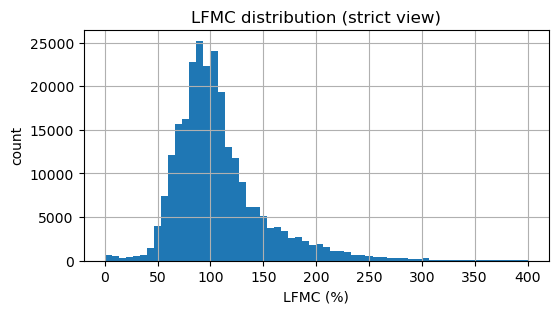

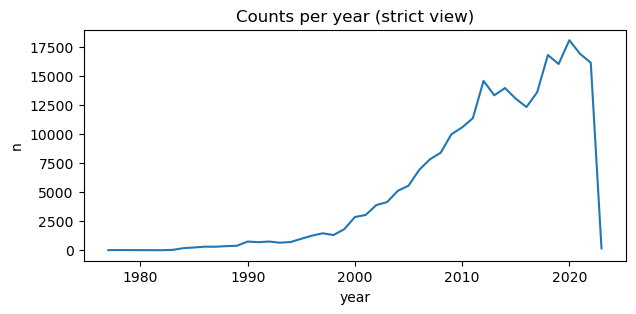

In [11]:
plt.figure(figsize=(6,3))
df_strict_live["lfmc_pct"].hist(bins=60)
plt.title("LFMC distribution (strict view)")
plt.xlabel("LFMC (%)")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,3))
df_strict_live.groupby("year")["lfmc_pct"].count().plot()
plt.title("Counts per year (strict view)")
plt.xlabel("year")
plt.ylabel("n")
plt.show()


## 10) 结果检查清单

运行成功后，你应该确认：
1. `df_raw` 行列数正常，且包含关键列。
2. `df_std` 里 `date` 不应大量缺失；`lat/lon` 范围合理；`lfmc_pct` 不是全 NaN。
3. `report` 中 `n_qc_hard` 比例合理（通常不会非常高）。
4. `df_site_day` 行数 <= `df_strict_live`，且 `n_obs` 大多为 1 或小整数。
5. 输出目录生成了 2 个 parquet + 1 个 json。

若异常：
- 首先检查 `configs/lfmc.yaml` 的 columns 映射是否与实际列名一致。


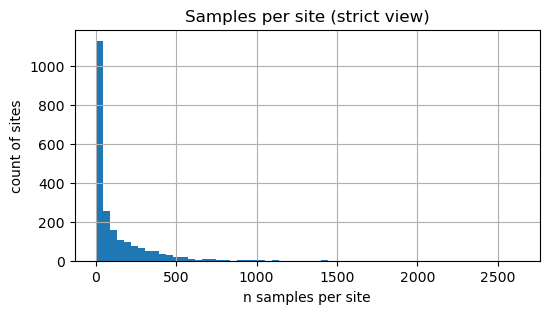

sites: 2158
site counts quantiles:
0.50     37.00
0.90    353.30
0.95    472.00
0.99    890.29
Name: lfmc_pct, dtype: float64


In [12]:
site_counts = df_strict_live.groupby("site_id")["lfmc_pct"].count()

plt.figure(figsize=(6,3))
site_counts.hist(bins=60)
plt.title("Samples per site (strict view)")
plt.xlabel("n samples per site")
plt.ylabel("count of sites")
plt.show()

print("sites:", site_counts.size)
print("site counts quantiles:")
print(site_counts.quantile([0.5, 0.9, 0.95, 0.99]))


In [2]:
import pandas as pd

path = r"G:\data\Globe LFMC\processed\lfmc_grid_day_0p1.parquet"  # 改成你的实际路径
df = pd.read_parquet(path)

# 1) 直接打印所有列名
print(df.columns.tolist())

# 2) 一行一个列名（更清晰）
for c in df.columns:
    print(c)

# 3) 同时看一下shape和前几行
print("shape:", df.shape)
df.head(3)


['date', 'grid_lat', 'grid_lon', 'veg_type', 'lfmc_pct', 'n_obs_sum', 'n_sites', 'source', 'n_records']
date
grid_lat
grid_lon
veg_type
lfmc_pct
n_obs_sum
n_sites
source
n_records
shape: (140112, 9)


,date,grid_lat,grid_lon,veg_type,lfmc_pct,n_obs_sum,n_sites,source,n_records
0,1977-04-14,37.25,-122.15,Shrub,176.0,1,1,US National Fuel Moisture Database https://www...,1
1,1977-04-14,37.45,-122.35,Shrub,203.0,1,1,US National Fuel Moisture Database https://www...,1
2,1977-04-15,37.05,-121.85,Shrub,96.0,1,1,US National Fuel Moisture Database https://www...,1
